<img src="../assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Logistic Regression Practice

---

# Titanic
On April 15, 1912, the RMS Titanic sank after colliding with an iceberg, killing over 1,500 of its 2,224 passengers and crew. Survival wasn't random — factors like class, sex, and age all played a role in who made it into a lifeboat.

You will be predicting `Survived`: whether a passenger survived (1) or did not (0), using their ticket and demographic information.

# Imports

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, recall_score, precision_score, f1_score

### 1. Load the data

Read in the `titanic.csv` data.

In [2]:
# TODO:
df = pd.read_csv('./data/titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 2. Drop columns that won’t help the model

> `PassengerId` is just a row ID, `Name` and `Ticket` are high-cardinality free text, and `Cabin` is missing for the vast majority of passengers.

In [3]:
# TODO:
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

### 3. Handle missing values

> Check for missing values. `Age` and `Embarked` both have null values, fill them in (median for `Age` and the most common value for `Embarked`).

In [5]:
# TODO:
df.isnull().sum()
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Modeling

### 4. Set up your target and features, and split into training and testing sets

Set `Survived` as your target, `y`. Everything else remaining is your feature matrix, `X`.

In [6]:
# TODO:
y = df['Survived']
X = df.drop(columns=['Survived'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


### 5. Establish a baseline

What accuracy would you get by always predicting the majority class? This is the number your model needs to beat.

In [7]:
# TODO:
dummy_clf = DummyClassifier(strategy='most_frequent')
dummy_clf.fit(X_train, y_train)
dummy_clf.score(X_test, y_test)

0.6145251396648045

### 6. Build a `Pipeline` with a `ColumnTransformer`

> Use a `ColumnTransformer` to scale your numeric features and encode your categorical features. Then chain it into a `Pipeline`.

In [8]:
# TODO:
num_cols = ['Age', 'SibSp', 'Parch', 'Fare', 'Pclass']
cat_cols = ['Sex', 'Embarked']

preprocessing = ColumnTransformer([
    ('scaler', StandardScaler(), num_cols),
    ('onehotencoder', OneHotEncoder(drop='first'), cat_cols)
])

pipe = Pipeline([
    ('preprocessing', preprocessing),
    ('logreg', LogisticRegression())
])


### 7. Fit your pipeline and evaluate train vs. test accuracy

Is there a meaningful gap between train and test performance? Is this model better than the null model?

In [9]:
# TODO:
pipe.fit(X_train, y_train)

pipe.score(X_train, y_train), pipe.score(X_test, y_test)

(0.8075842696629213, 0.8044692737430168)

### 8. Confusion matrix

> Generate a confusion matrix for your model's predictions on the test set. Which type of mistake is your model making more (predicting survival for someone who didn't, or the reverse?)

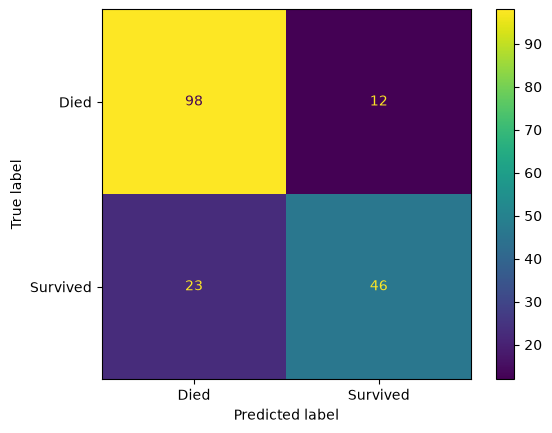

In [10]:
# TODO:
y_pred = pipe.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Died','Survived']).plot()


### 9. Classification report

> Print a classification report (precision, recall, f1-score) for the test set.

In [11]:
# TODO:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



# Interpretation & Predictions

### 10. Pull out your feature names and coefficients

> Your `ColumnTransformer` renames and reorders your columns when it transforms `X`, the numeric columns keep their original names, but the one-hot encoded categorical columns get new names like `Sex_male`. Before you can interpret any coefficient, you need to know which coefficient belongs to which feature.
>
> 1. Get the one-hot encoded feature names out of your fitted `ColumnTransformer` using:
>
>    `.named_steps['preprocessing'].named_transformers_['onehotencoder'].get_feature_names_out(cat_cols)`.
> 
> 2. Combine these with your numeric column names, **in the same order your `ColumnTransformer` outputs them** (e.g. numeric columns first, then categorical).
> 
> 3. Pair these feature names with your fitted model's `.coef_[0]` values in a `pandas.Series` (feature names as the index), so you can look up any coefficient by name.

In [12]:
# TODO:
cat_names = pipe.named_steps['preprocessing'].named_transformers_['onehotencoder'].get_feature_names_out(cat_cols)
feature_names = num_cols + list(cat_names)

coefs = pd.Series(pipe.named_steps['logreg'].coef_[0], index=feature_names)
coefs.sort_values()


Sex_male     -2.560338
Pclass       -0.915096
Age          -0.498458
Embarked_S   -0.381381
SibSp        -0.257118
Parch        -0.058899
Fare          0.102079
Embarked_Q    0.281546
dtype: float64

### 11. Interpret one coefficient

> Pick one feature and interpret its coefficient. Convert it from log-odds into an odds ratio (`np.exp(coef)`), and explain in a sentence what it does to the odds of survival.

In [13]:
# TODO:
np.exp(coefs['Sex_male'])

np.float64(0.07727861288690734)

### 12. Generate predictions and predicted probabilities

> Use your model to generate `.predict()` and `.predict_proba()` on the test set. Pick one test observation and explain, in a sentence, what its predicted probability means.

In [14]:
# TODO:
preds = pipe.predict(X_test)
probs = pipe.predict_proba(X_test)

i = 0
print(f"Predicted: {preds[i]}, P(survive) = {probs[i][1]:.2%}")


Predicted: 0, P(survive) = 6.97%


### 12. Try a different threshold

> `.predict()` uses a default threshold of 0.5 on `.predict_proba()` to decide the class. Try lowering it and recompute the confusion matrix and classification report at this new threshold. What trade-off do you see between precision and recall?

In [15]:
# TODO:
probs_survive = pipe.predict_proba(X_test)[:, 1]
y_pred_30 = (probs_survive >= 0.3).astype(int)

print(confusion_matrix(y_test, y_pred_30))
print(classification_report(y_test, y_pred_30))


[[81 29]
 [14 55]]
              precision    recall  f1-score   support

           0       0.85      0.74      0.79       110
           1       0.65      0.80      0.72        69

    accuracy                           0.76       179
   macro avg       0.75      0.77      0.75       179
weighted avg       0.78      0.76      0.76       179



### 13. Write a function to print classification metrics with explanations

> Write a function `print_classification_metrics(y_true, y_pred)` that calculates **accuracy**, **recall/sensitivity**, **precision**, **specificity**, and **F1 score**, and prints each metric alongside a clear explanation. Then call your function on your model's test set predictions.
>
> Use the confusion matrix layout below as your reference for which cells (`TP`, `TN`, `FP`, `FN`) each metric is built from.

**Accuracy** — Overall, how often is the classifier correct?

<table style="border: none">
<tr style="border: none">
    <td style="border: none; vertical-align: bottom; color: blue">n</td>
    <td><b>Predicted: Did Not Survive (0)</b></td>
    <td><b>Predicted: Survived (1)</b></td>
</tr>
<tr>
    <td><b>Actual: Did Not Survive (0)</b></td>
    <td style="text-align: center; background-color: red">TN</td>
    <td style="text-align: center">FP</td>
</tr>
<tr>
    <td><b>Actual: Survived (1)</b></td>
    <td style="text-align: center">FN</td>
    <td style="text-align: center; background-color: green">TP</td>
</tr>
</table>

$$\textbf{Accuracy} = \frac{TP + TN}{Total}$$

**Recall / Sensitivity / True Positive Rate (TPR)** — Among all passengers who actually survived, what proportion did we correctly detect?

<table style="border: none">
<tr style="border: none">
    <td style="border: none; vertical-align: bottom; color: blue">n</td>
    <td><b>Predicted: Did Not Survive (0)</b></td>
    <td><b>Predicted: Survived (1)</b></td>
</tr>
<tr>
    <td><b>Actual: Did Not Survive (0)</b></td>
    <td style="text-align: center">TN</td>
    <td style="text-align: center">FP</td>
</tr>
<tr>
    <td><b>Actual: Survived (1)</b></td>
    <td style="text-align: center; background-color: orchid">FN</td>
    <td style="text-align: center; background-color: green">TP</td>
</tr>
</table>

$$\textbf{Recall} = \frac{TP}{TP + FN}$$

**Precision** — Among all passengers predicted to survive, what proportion actually did?

<table style="border: none">
<tr style="border: none">
    <td style="border: none; vertical-align: bottom; color: blue">n</td>
    <td><b>Predicted: Did Not Survive (0)</b></td>
    <td><b>Predicted: Survived (1)</b></td>
</tr>
<tr>
    <td><b>Actual: Did Not Survive (0)</b></td>
    <td style="text-align: center">TN</td>
    <td style="text-align: center; background-color: orange">FP</td>
</tr>
<tr>
    <td><b>Actual: Survived (1)</b></td>
    <td style="text-align: center">FN</td>
    <td style="text-align: center; background-color: green">TP</td>
</tr>
</table>

$$\textbf{Precision} = \frac{TP}{TP + FP}$$

**Specificity / True Negative Rate (TNR)** — Among all passengers who did not actually survive, what proportion did we correctly detect?

<table style="border: none">
<tr style="border: none">
    <td style="border: none; vertical-align: bottom; color: blue">n</td>
    <td><b>Predicted: Did Not Survive (0)</b></td>
    <td><b>Predicted: Survived (1)</b></td>
</tr>
<tr>
    <td><b>Actual: Did Not Survive (0)</b></td>
    <td style="text-align: center; background-color: red">TN</td>
    <td style="text-align: center; background-color: orange">FP</td>
</tr>
<tr>
    <td><b>Actual: Survived (1)</b></td>
    <td style="text-align: center">FN</td>
    <td style="text-align: center">TP</td>
</tr>
</table>

$$\textbf{Specificity} = \frac{TN}{TN + FP}$$

**$F_1$ score** — The balance between precision and recall.

<table style="border: none">
<tr style="border: none">
    <td style="border: none; vertical-align: bottom; color: blue">n</td>
    <td><b>Predicted: Did Not Survive (0)</b></td>
    <td><b>Predicted: Survived (1)</b></td>
</tr>
<tr>
    <td><b>Actual: Did Not Survive (0)</b></td>
    <td style="text-align: center">TN</td>
    <td style="text-align: center; background-color: orange">FP</td>
</tr>
<tr>
    <td><b>Actual: Survived (1)</b></td>
    <td style="text-align: center; background-color: orchid">FN</td>
    <td style="text-align: center; background-color: green">TP</td>
</tr>
</table>

$$F_1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$


In [16]:
# TODO:

def print_classification_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    recall = tp / (tp + fn)
    precision = tp / (tp + fp)
    specificity = tn / (tn + fp)
    f1 = 2 * (precision * recall) / (precision + recall)

    print(f"Accuracy:    {accuracy:.3f}  — overall, how often is the classifier correct")
    print(f"Recall:      {recall:.3f}  — of passengers who survived, how many did we catch")
    print(f"Precision:   {precision:.3f}  — of passengers we predicted survived, how many actually did")
    print(f"Specificity: {specificity:.3f}  — of passengers who died, how many did we correctly flag")
    print(f"F1 score:    {f1:.3f}  — balance of precision and recall")

print_classification_metrics(y_test, y_pred)


Accuracy:    0.804  — overall, how often is the classifier correct
Recall:      0.667  — of passengers who survived, how many did we catch
Precision:   0.793  — of passengers we predicted survived, how many actually did
Specificity: 0.891  — of passengers who died, how many did we correctly flag
F1 score:    0.724  — balance of precision and recall
